In [ ]:
from datetime import datetime, timedelta, timezone
import pandas as pd
import numpy as np

file_id = '1j_pvqcNO3iw2-WyuNBbpdeenfzF5SksT'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

df = pd.read_csv(url)
df = df.set_index('t')
df

In [11]:
df['close_log_return'] = np.log(df['c'] / df['c'].shift(1))
df['close_log_return_lag_1'] = df['close_log_return'].shift(1)

df

,T,s,i,o,c,h,l,v,n,close_delta,close_log_return,close_log_return_lag_1,close_log_return_dir_lag_1
t,,,,,,,,,,,,,
2024-02-15,2024-02-21 23:59:59.999,TAO,1w,645.44,629.54,655.18,555.00,8029.029,7160,NaN,NaN,NaN,NaN
2024-02-22,2024-02-28 23:59:59.999,TAO,1w,632.18,609.53,670.00,474.64,65382.773,31527,-20.01,-0.032301,NaN,NaN
2024-02-29,2024-03-06 23:59:59.999,TAO,1w,611.15,716.31,756.93,601.30,41127.871,27815,106.78,0.161425,-0.032301,-1.0
2024-03-07,2024-03-13 23:59:59.999,TAO,1w,716.40,645.00,768.34,640.05,39401.087,32685,-71.31,-0.104863,0.161425,1.0
2024-03-14,2024-03-20 23:59:59.999,TAO,1w,646.88,687.00,766.09,550.00,36237.551,26883,42.00,0.063084,-0.104863,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09,2026-04-15 23:59:59.999,TAO,1w,324.88,241.37,341.49,236.25,1748773.823,503950,-83.61,-0.297433,0.055158,1.0
2026-04-16,2026-04-22 23:59:59.999,TAO,1w,241.27,245.56,267.25,233.67,414347.782,156956,4.19,0.017210,-0.297433,-1.0
2026-04-23,2026-04-29 23:59:59.999,TAO,1w,245.82,253.91,266.56,240.55,268821.131,100710,8.35,0.033439,0.017210,1.0


In [12]:
df[['close_log_return', 'close_log_return_lag_1']].corr()

,close_log_return,close_log_return_lag_1
close_log_return,1.000000,0.033872
close_log_return_lag_1,0.033872,1.000000


In [10]:
df['close_log_return_dir_lag_1'] = np.sign(df['close_log_return_lag_1'])

In [ ]:
df

In [15]:
df.groupby('close_log_return_dir_lag_1').aggregate({'close_log_return': ['sum','mean','count']})

close_log_return                
                                        sum      mean count
close_log_return_dir_lag_1                                 
-1.0                              -1.133618 -0.018894    60
 1.0                               0.475563  0.008647    55

In [16]:
i = int(len(df) * 0.75)
in_sample, out_sample = df.iloc[:i], df.iloc[i:]


In [17]:
in_sample.groupby('close_log_return_dir_lag_1').aggregate({'close_log_return': ['sum','mean','count']})

close_log_return                
                                        sum      mean count
close_log_return_dir_lag_1                                 
-1.0                              -0.557479 -0.012670    44
 1.0                               0.165595  0.004039    41

In [18]:
out_sample.groupby('close_log_return_dir_lag_1').aggregate({'close_log_return': ['sum','mean','count']})

close_log_return                
                                        sum      mean count
close_log_return_dir_lag_1                                 
-1.0                              -0.576139 -0.036009    16
 1.0                               0.309968  0.022141    14

In [20]:
df["signal"] = df['close_log_return_dir_lag_1']
df

,T,s,i,o,c,h,l,v,n,close_delta,close_log_return,close_log_return_lag_1,close_log_return_dir_lag_1,signal
t,,,,,,,,,,,,,,
2024-02-15,2024-02-21 23:59:59.999,TAO,1w,645.44,629.54,655.18,555.00,8029.029,7160,NaN,NaN,NaN,NaN,NaN
2024-02-22,2024-02-28 23:59:59.999,TAO,1w,632.18,609.53,670.00,474.64,65382.773,31527,-20.01,-0.032301,NaN,NaN,NaN
2024-02-29,2024-03-06 23:59:59.999,TAO,1w,611.15,716.31,756.93,601.30,41127.871,27815,106.78,0.161425,-0.032301,-1.0,-1.0
2024-03-07,2024-03-13 23:59:59.999,TAO,1w,716.40,645.00,768.34,640.05,39401.087,32685,-71.31,-0.104863,0.161425,1.0,1.0
2024-03-14,2024-03-20 23:59:59.999,TAO,1w,646.88,687.00,766.09,550.00,36237.551,26883,42.00,0.063084,-0.104863,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09,2026-04-15 23:59:59.999,TAO,1w,324.88,241.37,341.49,236.25,1748773.823,503950,-83.61,-0.297433,0.055158,1.0,1.0
2026-04-16,2026-04-22 23:59:59.999,TAO,1w,241.27,245.56,267.25,233.67,414347.782,156956,4.19,0.017210,-0.297433,-1.0,-1.0
2026-04-23,2026-04-29 23:59:59.999,TAO,1w,245.82,253.91,266.56,240.55,268821.131,100710,8.35,0.033439,0.017210,1.0,1.0


In [22]:
df['trade_log_return'] = df['signal'] * df['close_log_return']

df

,T,s,i,o,c,h,l,v,n,close_delta,close_log_return,close_log_return_lag_1,close_log_return_dir_lag_1,signal,trade_log_return
t,,,,,,,,,,,,,,,
2024-02-15,2024-02-21 23:59:59.999,TAO,1w,645.44,629.54,655.18,555.00,8029.029,7160,NaN,NaN,NaN,NaN,NaN,NaN
2024-02-22,2024-02-28 23:59:59.999,TAO,1w,632.18,609.53,670.00,474.64,65382.773,31527,-20.01,-0.032301,NaN,NaN,NaN,NaN
2024-02-29,2024-03-06 23:59:59.999,TAO,1w,611.15,716.31,756.93,601.30,41127.871,27815,106.78,0.161425,-0.032301,-1.0,-1.0,-0.161425
2024-03-07,2024-03-13 23:59:59.999,TAO,1w,716.40,645.00,768.34,640.05,39401.087,32685,-71.31,-0.104863,0.161425,1.0,1.0,-0.104863
2024-03-14,2024-03-20 23:59:59.999,TAO,1w,646.88,687.00,766.09,550.00,36237.551,26883,42.00,0.063084,-0.104863,-1.0,-1.0,-0.063084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09,2026-04-15 23:59:59.999,TAO,1w,324.88,241.37,341.49,236.25,1748773.823,503950,-83.61,-0.297433,0.055158,1.0,1.0,-0.297433
2026-04-16,2026-04-22 23:59:59.999,TAO,1w,241.27,245.56,267.25,233.67,414347.782,156956,4.19,0.017210,-0.297433,-1.0,-1.0,-0.017210
2026-04-23,2026-04-29 23:59:59.999,TAO,1w,245.82,253.91,266.56,240.55,268821.131,100710,8.35,0.033439,0.017210,1.0,1.0,0.033439


In [24]:
df['cum_trade_log_return'] = df['trade_log_return'].cumsum()

In [25]:
df

,T,s,i,o,c,h,l,v,n,close_delta,close_log_return,close_log_return_lag_1,close_log_return_dir_lag_1,signal,trade_log_return,cum_trade_log_return
t,,,,,,,,,,,,,,,,
2024-02-15,2024-02-21 23:59:59.999,TAO,1w,645.44,629.54,655.18,555.00,8029.029,7160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-02-22,2024-02-28 23:59:59.999,TAO,1w,632.18,609.53,670.00,474.64,65382.773,31527,-20.01,-0.032301,NaN,NaN,NaN,NaN,NaN
2024-02-29,2024-03-06 23:59:59.999,TAO,1w,611.15,716.31,756.93,601.30,41127.871,27815,106.78,0.161425,-0.032301,-1.0,-1.0,-0.161425,-0.161425
2024-03-07,2024-03-13 23:59:59.999,TAO,1w,716.40,645.00,768.34,640.05,39401.087,32685,-71.31,-0.104863,0.161425,1.0,1.0,-0.104863,-0.266288
2024-03-14,2024-03-20 23:59:59.999,TAO,1w,646.88,687.00,766.09,550.00,36237.551,26883,42.00,0.063084,-0.104863,-1.0,-1.0,-0.063084,-0.329372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09,2026-04-15 23:59:59.999,TAO,1w,324.88,241.37,341.49,236.25,1748773.823,503950,-83.61,-0.297433,0.055158,1.0,1.0,-0.297433,1.375299
2026-04-16,2026-04-22 23:59:59.999,TAO,1w,241.27,245.56,267.25,233.67,414347.782,156956,4.19,0.017210,-0.297433,-1.0,-1.0,-0.017210,1.358088
2026-04-23,2026-04-29 23:59:59.999,TAO,1w,245.82,253.91,266.56,240.55,268821.131,100710,8.35,0.033439,0.017210,1.0,1.0,0.033439,1.391527


<Axes: xlabel='t'>

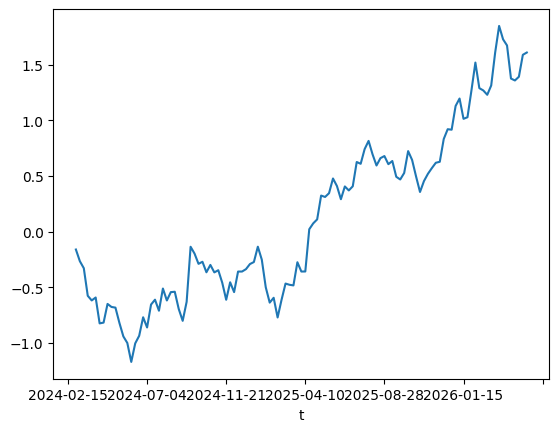

In [30]:
df['cum_trade_log_return'].plot()

In [31]:
df['is_won'] = df['trade_log_return'] > 0
df['is_won'].mean()

np.float64(0.5299145299145299)

In [32]:
df['trade_log_return'].mean()

np.float64(0.01399287738984498)

In [35]:
Capital = 1000

df['post-trade_capital'] = Capital * np.exp(df['cum_trade_log_return'])

df['post_trade_notional'] = Capital + Capital * df['cum_trade_log_return']

df

,T,s,i,o,c,h,l,v,n,close_delta,close_log_return,close_log_return_lag_1,close_log_return_dir_lag_1,signal,trade_log_return,cum_trade_log_return,is_won,post-trade_capital,post_trade_notional
t,,,,,,,,,,,,,,,,,,,
2024-02-15,2024-02-21 23:59:59.999,TAO,1w,645.44,629.54,655.18,555.00,8029.029,7160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
2024-02-22,2024-02-28 23:59:59.999,TAO,1w,632.18,609.53,670.00,474.64,65382.773,31527,-20.01,-0.032301,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
2024-02-29,2024-03-06 23:59:59.999,TAO,1w,611.15,716.31,756.93,601.30,41127.871,27815,106.78,0.161425,-0.032301,-1.0,-1.0,-0.161425,-0.161425,False,850.930463,838.575134
2024-03-07,2024-03-13 23:59:59.999,TAO,1w,716.40,645.00,768.34,640.05,39401.087,32685,-71.31,-0.104863,0.161425,1.0,1.0,-0.104863,-0.266288,False,766.218744,733.712417
2024-03-14,2024-03-20 23:59:59.999,TAO,1w,646.88,687.00,766.09,550.00,36237.551,26883,42.00,0.063084,-0.104863,-1.0,-1.0,-0.063084,-0.329372,False,719.375677,670.628441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09,2026-04-15 23:59:59.999,TAO,1w,324.88,241.37,341.49,236.25,1748773.823,503950,-83.61,-0.297433,0.055158,1.0,1.0,-0.297433,1.375299,False,3956.257498,2375.298502
2026-04-16,2026-04-22 23:59:59.999,TAO,1w,241.27,245.56,267.25,233.67,414347.782,156956,4.19,0.017210,-0.297433,-1.0,-1.0,-0.017210,1.358088,False,3888.751720,2358.088212
2026-04-23,2026-04-29 23:59:59.999,TAO,1w,245.82,253.91,266.56,240.55,268821.131,100710,8.35,0.033439,0.017210,1.0,1.0,0.033439,1.391527,True,4020.984481,2391.526769


In [59]:
df['pre_trade_notional_value'] = df['post_trade_notional'].shift()
df['pre_trade_notional_value'].fillna(Capital, inplace=True)

df

,T,s,i,o,c,h,l,v,n,close_delta,...,is_won,post-trade_capital,post_trade_notional,pre_trade_notional_value,taker_fee,maker_fee,tx_fees,cum_tx_fees,entry_fee,exit_fee
t,,,,,,,,,,,,,,,,,,,,,
2024-02-15,2024-02-21 23:59:59.999,TAO,1w,645.44,629.54,655.18,555.00,8029.029,7160,NaN,...,False,NaN,NaN,1000.000000,0.410000,NaN,NaN,NaN,NaN,NaN
2024-02-22,2024-02-28 23:59:59.999,TAO,1w,632.18,609.53,670.00,474.64,65382.773,31527,-20.01,...,False,NaN,NaN,1000.000000,0.410000,NaN,NaN,NaN,NaN,NaN
2024-02-29,2024-03-06 23:59:59.999,TAO,1w,611.15,716.31,756.93,601.30,41127.871,27815,106.78,...,False,850.930463,838.575134,1000.000000,0.410000,0.100629,NaN,0.753816,NaN,0.838575
2024-03-07,2024-03-13 23:59:59.999,TAO,1w,716.40,645.00,768.34,640.05,39401.087,32685,-71.31,...,False,766.218744,733.712417,838.575134,0.343816,0.088045,1.572288,1.398454,0.838575,0.733712
2024-03-14,2024-03-20 23:59:59.999,TAO,1w,646.88,687.00,766.09,550.00,36237.551,26883,42.00,...,False,719.375677,670.628441,733.712417,0.300822,0.080475,1.404341,1.974233,0.733712,0.670628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09,2026-04-15 23:59:59.999,TAO,1w,324.88,241.37,341.49,236.25,1748773.823,503950,-83.61,...,False,3956.257498,2375.298502,2672.731118,1.095820,0.285036,5.048030,96.931872,2.672731,2.375299
2026-04-16,2026-04-22 23:59:59.999,TAO,1w,241.27,245.56,267.25,233.67,414347.782,156956,4.19,...,False,3888.751720,2358.088212,2375.298502,0.973872,0.282971,4.733387,98.872561,2.375299,2.358088
2026-04-23,2026-04-29 23:59:59.999,TAO,1w,245.82,253.91,266.56,240.55,268821.131,100710,8.35,...,True,4020.984481,2391.526769,2358.088212,0.966816,0.286983,4.749615,100.819903,2.358088,2.391527


In [72]:
TAKER_FEE_BPS = 10
MAKER_FEE_BPS = 10


TAKER_FEE_PCT = TAKER_FEE_BPS / 10000
MAKER_FEE_PCT = MAKER_FEE_BPS / 10000

df['entry_fee'] = df['pre_trade_notional_value'] * TAKER_FEE_PCT
df['exit_fee'] = df['post_trade_notional'] * TAKER_FEE_PCT
df['tx_fees'] = df['entry_fee'] + df['exit_fee']

<Axes: xlabel='t'>

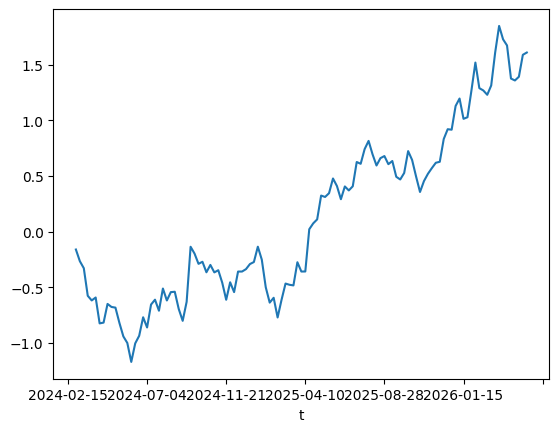

In [73]:
df['cum_trade_log_return'].plot()

In [74]:
df['net_equity'] = df['post_trade_notional'] - df['cum_tx_fees']

,T,s,i,o,c,h,l,v,n,close_delta,...,post-trade_capital,post_trade_notional,pre_trade_notional_value,taker_fee,maker_fee,tx_fees,cum_tx_fees,entry_fee,exit_fee,net_equity
t,,,,,,,,,,,,,,,,,,,,,
2024-02-15,2024-02-21 23:59:59.999,TAO,1w,645.44,629.54,655.18,555.00,8029.029,7160,NaN,...,NaN,NaN,1000.000000,0.410000,NaN,NaN,NaN,1.000000,NaN,NaN
2024-02-22,2024-02-28 23:59:59.999,TAO,1w,632.18,609.53,670.00,474.64,65382.773,31527,-20.01,...,NaN,NaN,1000.000000,0.410000,NaN,NaN,NaN,1.000000,NaN,NaN
2024-02-29,2024-03-06 23:59:59.999,TAO,1w,611.15,716.31,756.93,601.30,41127.871,27815,106.78,...,850.930463,838.575134,1000.000000,0.410000,0.100629,1.838575,0.753816,1.000000,0.838575,837.821318
2024-03-07,2024-03-13 23:59:59.999,TAO,1w,716.40,645.00,768.34,640.05,39401.087,32685,-71.31,...,766.218744,733.712417,838.575134,0.343816,0.088045,1.572288,1.398454,0.838575,0.733712,732.313963
2024-03-14,2024-03-20 23:59:59.999,TAO,1w,646.88,687.00,766.09,550.00,36237.551,26883,42.00,...,719.375677,670.628441,733.712417,0.300822,0.080475,1.404341,1.974233,0.733712,0.670628,668.654208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09,2026-04-15 23:59:59.999,TAO,1w,324.88,241.37,341.49,236.25,1748773.823,503950,-83.61,...,3956.257498,2375.298502,2672.731118,1.095820,0.285036,5.048030,96.931872,2.672731,2.375299,2278.366630
2026-04-16,2026-04-22 23:59:59.999,TAO,1w,241.27,245.56,267.25,233.67,414347.782,156956,4.19,...,3888.751720,2358.088212,2375.298502,0.973872,0.282971,4.733387,98.872561,2.375299,2.358088,2259.215651
2026-04-23,2026-04-29 23:59:59.999,TAO,1w,245.82,253.91,266.56,240.55,268821.131,100710,8.35,...,4020.984481,2391.526769,2358.088212,0.966816,0.286983,4.749615,100.819903,2.358088,2.391527,2290.706865


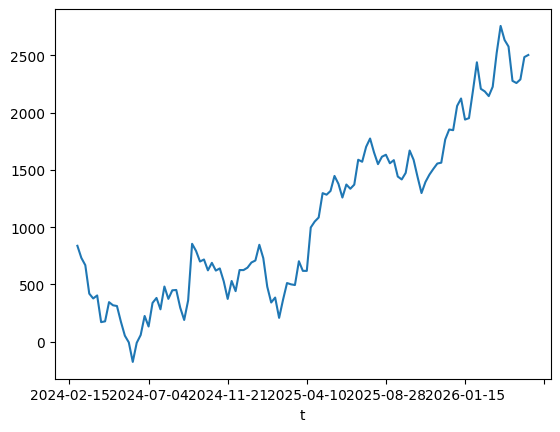

In [75]:
df['net_equity'].plot()
df

In [77]:
df

,T,s,i,o,c,h,l,v,n,close_delta,...,post-trade_capital,post_trade_notional,pre_trade_notional_value,taker_fee,maker_fee,tx_fees,cum_tx_fees,entry_fee,exit_fee,net_equity
t,,,,,,,,,,,,,,,,,,,,,
2024-02-15,2024-02-21 23:59:59.999,TAO,1w,645.44,629.54,655.18,555.00,8029.029,7160,NaN,...,NaN,NaN,1000.000000,0.410000,NaN,NaN,NaN,1.000000,NaN,NaN
2024-02-22,2024-02-28 23:59:59.999,TAO,1w,632.18,609.53,670.00,474.64,65382.773,31527,-20.01,...,NaN,NaN,1000.000000,0.410000,NaN,NaN,NaN,1.000000,NaN,NaN
2024-02-29,2024-03-06 23:59:59.999,TAO,1w,611.15,716.31,756.93,601.30,41127.871,27815,106.78,...,850.930463,838.575134,1000.000000,0.410000,0.100629,1.838575,0.753816,1.000000,0.838575,837.821318
2024-03-07,2024-03-13 23:59:59.999,TAO,1w,716.40,645.00,768.34,640.05,39401.087,32685,-71.31,...,766.218744,733.712417,838.575134,0.343816,0.088045,1.572288,1.398454,0.838575,0.733712,732.313963
2024-03-14,2024-03-20 23:59:59.999,TAO,1w,646.88,687.00,766.09,550.00,36237.551,26883,42.00,...,719.375677,670.628441,733.712417,0.300822,0.080475,1.404341,1.974233,0.733712,0.670628,668.654208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09,2026-04-15 23:59:59.999,TAO,1w,324.88,241.37,341.49,236.25,1748773.823,503950,-83.61,...,3956.257498,2375.298502,2672.731118,1.095820,0.285036,5.048030,96.931872,2.672731,2.375299,2278.366630
2026-04-16,2026-04-22 23:59:59.999,TAO,1w,241.27,245.56,267.25,233.67,414347.782,156956,4.19,...,3888.751720,2358.088212,2375.298502,0.973872,0.282971,4.733387,98.872561,2.375299,2.358088,2259.215651
2026-04-23,2026-04-29 23:59:59.999,TAO,1w,245.82,253.91,266.56,240.55,268821.131,100710,8.35,...,4020.984481,2391.526769,2358.088212,0.966816,0.286983,4.749615,100.819903,2.358088,2.391527,2290.706865
